## Import Required Libraries

In [1]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sklearn packages
from sklearn.preprocessing import (StandardScaler, 
                                    MinMaxScaler)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, train_test_split

from sklearn.metrics import (accuracy_score, 
                            classification_report, 
                            confusion_matrix, 
                            ConfusionMatrixDisplay)


# MNE Packages
import mne
from mne.datasets.sleep_physionet.age import fetch_data
mne.utils.set_config('MNE_USE_CUDA', 'true')

## Step -1 Loading the Data

In [3]:
# Notes : Based on PTP the signal are automatically dropped in mne while reading the epoch level

In [4]:
class EEGEpochExtractor:
    def __init__(self, data_dir):
        """
        Initialize the extractor with the directory containing EDF files.
        """
        self.data_dir = data_dir
        self.all_epochs = []

    # --- Trail classification ---
    @staticmethod
    def trail_classification(trail_num: int) -> str:
        if trail_num in [4, 6, 8, 10, 12, 14]:
            return "imaginary"
        elif trail_num in [1, 2]:
            return "baseline"
        else:
            return "motor"

    # --- Event type classification ---
    @staticmethod
    def event_type_classification(trail_num: int):
        if trail_num in [1, 2]:
            return ("rest", "NA", "NA")
        elif trail_num in [3, 4, 7, 8, 11, 12]:
            return ("rest", "left_fist", "right_fist")
        elif trail_num in [5, 6, 9, 10, 13, 14]:
            return ("rest", "both_fist", "both_feet")

    # --- Metadata extraction ---
    def extract_metadata(self) -> pd.DataFrame:
        metadata = []

        for subj in sorted(os.listdir(self.data_dir)):
            subj_path = os.path.join(self.data_dir, subj)
            if not os.path.isdir(subj_path):
                continue

            for file in sorted(os.listdir(subj_path)):
                if file.endswith(".edf") and not file.endswith(".edf.event"):
                    match = re.search(r"R(\d{2})\.edf$", file)
                    if match:
                        trial_num = int(match.group(1))
                        trail_type = self.trail_classification(trial_num)
                        event_type = self.event_type_classification(trial_num)

                        edf_file = os.path.join(subj_path, file)
                        event_file = edf_file + ".event" if os.path.exists(edf_file + ".event") else None

                        metadata.append({
                            "subject": subj,
                            "trial": trial_num,
                            "trail_type": trail_type,
                            "edf_file": edf_file,
                            "event_file": event_file,
                            "T0": event_type[0],
                            "T1": event_type[1],
                            "T2": event_type[2],
                        })

        self.metadata_df = pd.DataFrame(metadata)
        return self.metadata_df


    def process_file(self, file_path, event_id_mapping):
        """
        Process a single EDF file and return epochs.
        """
        print(f"Processing: {file_path}")
        raw_edf = mne.io.read_raw_edf(file_path, preload=True)
        annotations_edf = mne.read_annotations(file_path)

        # Update annotation descriptions
        new_descriptions = [
            event_id_mapping.get(desc, desc) for desc in annotations_edf.description
        ]
        annotations_edf.description = new_descriptions
        
        # Set updated annotations
        raw_edf.set_annotations(annotations_edf)
        
        # Convert annotations to events
        events, event_id = mne.events_from_annotations(raw_edf)
        
        
        epochs = mne.Epochs(
            raw=raw_edf,
            events=events,
            event_id= event_id,
            reject = None,
            flat = None, 
            reject_by_annotation= False, 
            baseline=None,
            preload=True
        )
        return epochs

    def process_all(self):
        """
        Process all EDF files in the directory and store their epochs.
        """
        metadata_info = self.extract_metadata() # Metadata Information
        self.all_epochs = []  # reset list
        for filename in metadata_info["edf_file"].tolist():
            if filename.endswith(".edf"):
                event_id_mapping = {"T0": metadata_info[(metadata_info["edf_file"]==filename)]["T0"].values[0], 
                                    "T1": metadata_info[(metadata_info["edf_file"]==filename)]["T1"].values[0], 
                                    "T2": metadata_info[(metadata_info["edf_file"]==filename)]["T2"].values[0]}
                print(event_id_mapping)
                epochs = self.process_file(file_path=filename, event_id_mapping= event_id_mapping)
                self.all_epochs.append(epochs)
        
        print(f"\nTotal EDF files processed: {len(self.all_epochs)}")
        return self.all_epochs


In [5]:
extractor = EEGEpochExtractor(data_dir= "../data/Original/")
all_epochs = extractor.process_all()

{'T0': 'rest', 'T1': 'NA', 'T2': 'NA'}
Processing: ../data/Original/S001/S001R01.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Used Annotations descriptions: [np.str_('rest')]
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'NA', 'T2': 'NA'}
Processing: ../data/Original/S001/S001R02.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_71649/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_71649/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S001/S001R10.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R10.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs drop

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_71649/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_71649/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S002/S002R10.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S002/S002R10.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs drop

...

No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S107/S107R10.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S107/S107R10.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'left_fist', 'T2': 'right_fist'}
Processing: ../data/Original/S107/S107R11.edf
Extracting EDF parameters from /Use

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_71649/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_71649/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S108/S108R10.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S108/S108R10.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs drop

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_71649/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_71649/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S109/S109R10.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S109/S109R10.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'left_fist', 'T2': 'right_fist'}
Processing: ../data/Original/S109/S109R11.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S109/S109R11.edf...


In [6]:
all_epochs[2]

<Epochs | 29 events (all good), -0.2 – 0.5 s (baseline off), ~1.7 MiB, data loaded,
 np.str_('left_fist'): 8
 np.str_('rest'): 14
 np.str_('right_fist'): 7>

## Step -2 : Feature Calculation

In [7]:
# Frequency bands range in Hz for EEG
FREQ_BANDS = {
    "delta": [0.5, 4.5],
    "theta": [4.5, 8.5],
    "alpha": [8.5, 11.5],
    "sigma": [11.5, 15.5],
    "beta": [15.5, 30],
}

In [8]:
def eeg_power_band(epochs, freq_bands=FREQ_BANDS):
  """Calculate relative spectral analysis on the EEG sensors for each epochs"""

  # Calculate the spectrogram
  spectrum = epochs.compute_psd(picks="eeg", fmin=0.5, fmax=30.0)
  psds, freqs = spectrum.get_data(return_freqs=True)

  # Normalization
  psds /= np.sum(psds, axis=-1, keepdims=True)

  # shape of PSDS:
  # (epoch, number of channels (we have two), frequency_bins)
  # We'll slice and average to get the delta to theta bands (5 feature per channel)
  # Therefore we should finish with (epoch, number of channels * number of bands)

  X = []
  # For each frequency band get the mean value and add it to the list X
  for fmin, fmax in freq_bands.values():
    psds_band = psds[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)
    X.append(psds_band.reshape(len(psds), -1))

  # return a numpy array, by reshuffling the list from a (5,841,2) to a (841,10)
  return np.concatenate(X, axis=1)

In [9]:
# Iterate over the 30 seconds epochs, calculate the proper powerband features
# Then define the right id for the "group" which should be the participant_id

X = []
y = []
groups = []
for group_id, epochs in enumerate(all_epochs):
  try:
    print(f"Processing participants #{group_id}")

    X_epoch = eeg_power_band(epochs)
    y_epoch_event_mapping = epochs.event_id
    y_epoch = epochs.events[:, 2]

    # y_epoch into a categorical variable
    y_epoch = np.array(y_epoch, dtype = object)
    for key, value in y_epoch_event_mapping.items():
        y_epoch[y_epoch == value] = str(key)

    y_epoch = list(y_epoch)

    group_epoch = [group_id]*len(y_epoch)

    X.append(X_epoch)
    y.append(y_epoch)
    groups.append(group_epoch)
  except:
    print(f"Error Processing Participants #{group_id}")

# Transform these lists into numpy array with proper size for sklearn models
X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)
groups = np.concatenate(groups, axis=0)

Processing participants #0
Error Processing Participants #0
Processing participants #1
Error Processing Participants #1
Processing participants #2
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #3
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #4
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #5
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #6
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #7
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #8
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #9
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #10
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #11
    Using multitaper spectrum estimation with 7 DPSS window

In [10]:
Y_CAT_MAPPING = {"rest" : 0,
                "both_feet" : 1, 
                "both_fist" : 2, 
                "left_fist" : 3, 
                "right_fist" : 4}

for key, value in Y_CAT_MAPPING.items():
        y[y == key] = value

## Step 3 : Train, Valid and Test Splits

In [12]:
train_len = int(np.floor(np.unique(groups).shape[0] * 0.80))
valid_len = int(np.floor(np.unique(groups).shape[0] * 0.10))
test_len = int(np.unique(groups).shape[0] - (train_len+valid_len))
print(f"Train : {train_len}, Valid : {valid_len} and Test : {test_len}")
train_groups = np.random.choice(groups, size = train_len, replace = False)
valid_groups = np.random.choice(groups, size = valid_len, replace = False)
test_groups = np.random.choice(groups, size = test_len, replace = False)

# Generate the train and Valid sets
X_train, X_valid = X[np.isin(groups, train_groups)], X[np.isin(groups, valid_groups)]
y_train, y_valid = y[np.isin(groups, train_groups)], y[np.isin(groups, valid_groups)]

X_test = X[np.isin(groups, test_groups)]
y_test = y[np.isin(groups, test_groups)]

print("Shape of X_train Dataset", X_train.shape)
print("Shape of y_train Dataset", y_train.shape)
print("Shape of X_valid Dataset", X_valid.shape)
print("Shape of y_valid Dataset", y_valid.shape)
print("Shape of X_test Dataset", X_test.shape)
print("Shape of y_test Dataset", y_test.shape)


Train : 1046, Valid : 130 and Test : 132
Shape of X_train Dataset (20776, 320)
Shape of y_train Dataset (20776,)
Shape of X_valid Dataset (3596, 320)
Shape of y_valid Dataset (3596,)
Shape of X_test Dataset (3686, 320)
Shape of y_test Dataset (3686,)


In [16]:
np.savez("../data/mne/train.npz", X_train, y_train)
np.savez("../data/mne/valid.npz", X_valid, y_valid)
np.savez("../data/mne/test.npz", X_test, y_test)

In [2]:
TRAIN_FILE_PATH = "../data/mne/train.npz"
VALID_FILE_PATH = "../data/mne/valid.npz"
TEST_FILE_PATH = "../data/mne/test.npz"

In [3]:
# Train
train = np.load(TRAIN_FILE_PATH)
X_train, y_train = train["arr_0"], train["arr_1"].astype(int)

# Valid
valid = np.load(VALID_FILE_PATH)
X_valid, y_valid = valid["arr_0"], valid["arr_1"].astype(int)

X, y = np.vstack([X_train, X_valid]), np.hstack([y_train, y_valid])

# Test
test = np.load(TEST_FILE_PATH)
X_test, y_test = test["arr_0"], test["arr_1"].astype(int)

print(f"Shape of X_train : {X_train.shape} and y_train : {y_train.shape}")
print(f"Shape of X_val : {X_valid.shape} and y_valid : {y_valid.shape}")
print(f"Shape of X_test : {X_test.shape} and y_test : {y_test.shape}")

Shape of X_train : (20776, 320) and y_train : (20776,)
Shape of X_val : (3596, 320) and y_valid : (3596,)
Shape of X_test : (3686, 320) and y_test : (3686,)


In [4]:
X = X[(y != 0)]
X_test = X_test[(y_test != 0)]

In [5]:
y = y[(y != 0)]
y_test = y_test[(y_test != 0)]

## Step 4 : Random Forest Model

In [6]:
def tune_random_forest_full(X, y, n_iter=20, random_state=42):
    """
    Tune RandomForestClassifier using RandomizedSearchCV on the full dataset
    and return the best model trained on all data.

    Parameters:
    -----------
    X : array-like
        Feature matrix.
    y : array-like
        Target labels.
    n_iter : int, optional
        Number of random parameter combinations to try. Default = 20
    random_state : int, optional
        Seed for reproducibility. Default = 42

    Returns:
    --------
    best_model : RandomForestClassifier
        Random Forest model trained on the full dataset with best hyperparameters.
    """

    # --- Base Random Forest --- #
    rf = RandomForestClassifier(random_state=random_state)

    # --- Parameter space --- #
    param_distributions = {
        'n_estimators': [100],#, 200, 300, 500],
        'max_depth': [None, 10, 20, 30, 40],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None],
    }

    # --- Randomized Search with 5-fold CV --- #
    rf_random = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_distributions,
        n_iter=n_iter,
        cv=5,                   # cross-validation folds
        verbose=2,
        random_state=random_state,
        n_jobs=-1
    )

    # --- Fit search on full dataset --- #
    rf_random.fit(X, y)

    # --- Return the best model trained on all data --- #
    best_model = rf_random.best_estimator_
    print(rf_random.best_estimator_)
    best_model.fit(X, y)  # retrain on full dataset
    return best_model

best_rf = tune_random_forest_full(X, y, n_iter=2)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   6.2s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   6.2s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   6.4s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   6.4s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   6.4s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   6.5s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   6.6s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators

#### Step 4.1 Train Predictions

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      3223
           2       1.00      1.00      1.00      3231
           3       0.99      1.00      1.00      3105
           4       1.00      1.00      1.00      3046

    accuracy                           1.00     12605
   macro avg       1.00      1.00      1.00     12605
weighted avg       1.00      1.00      1.00     12605



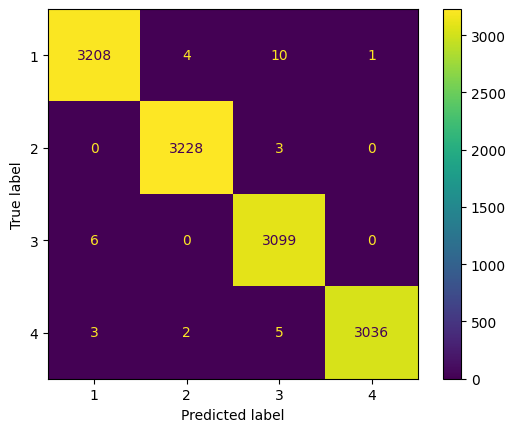

In [7]:
y_train_pred = best_rf.predict(X)
# Confusion Matrix
cm = confusion_matrix(y, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y, y_train_pred, ))

#### Step 4.2 Test Predictions

              precision    recall  f1-score   support

           1       0.73      0.75      0.74       503
           2       0.75      0.76      0.75       499
           3       0.77      0.73      0.75       452
           4       0.75      0.76      0.76       452

    accuracy                           0.75      1906
   macro avg       0.75      0.75      0.75      1906
weighted avg       0.75      0.75      0.75      1906



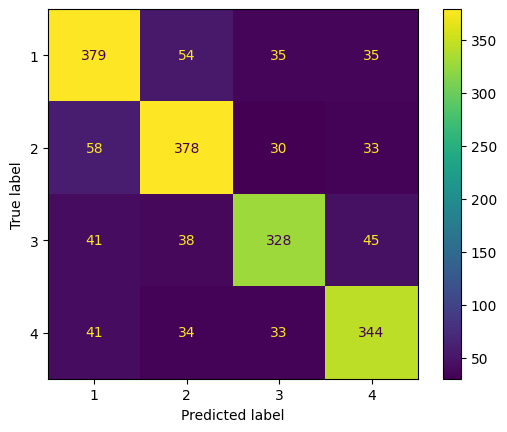

In [9]:
y_pred = best_rf.predict(X_test)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_test, y_pred, ))

## Step 5 : SVM Model

In [10]:
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, train_test_split
from sklearn.svm import SVC

# --- Parameter ranges (smaller but effective) --- #
C_range = np.logspace(-2, 4, 7)
gamma_range = np.logspace(-6, 1, 7)
param_grid = dict(C=C_range, gamma=gamma_range)

# --- Cross-validation setup --- #
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# --- Use a subset for faster tuning --- #
X_sub, _, y_sub, _ = train_test_split(
    X, y, train_size=5000, stratify=y, random_state=42
)

# --- Randomized Search with parallelization --- #
grid = RandomizedSearchCV(
    SVC(kernel='rbf'),
    param_distributions=param_grid,
    n_iter=20,            # sample only 20 parameter combinations
    cv=cv,
    n_jobs=-1,            # use all CPU cores
    random_state=42,
    verbose=1
)

# --- Fit on the subset --- #
grid.fit(X_sub, y_sub)

print("Best parameters:", grid.best_params_)
print("Best CV score: %.2f" % grid.best_score_)

# --- Retrain final model on full data --- #
best_model = SVC(kernel='rbf', **grid.best_params_)
best_model.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'gamma': np.float64(0.6812920690579622), 'C': np.float64(10.0)}
Best CV score: 0.40


SVC(C=np.float64(10.0), gamma=np.float64(0.6812920690579622))

# Train Predictions

              precision    recall  f1-score   support

           1       0.50      0.58      0.54      3223
           2       0.47      0.56      0.51      3231
           3       0.58      0.47      0.52      3105
           4       0.56      0.46      0.50      3046

    accuracy                           0.52     12605
   macro avg       0.53      0.52      0.52     12605
weighted avg       0.53      0.52      0.52     12605



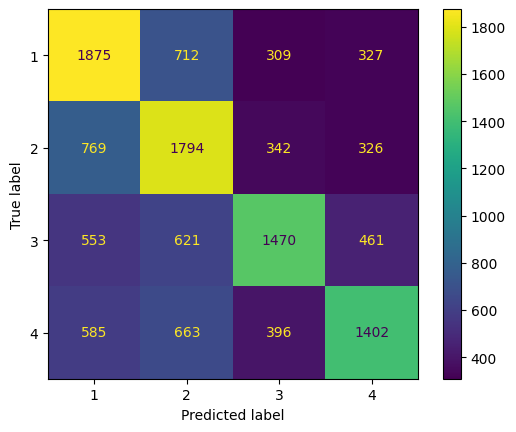

In [11]:
# Model Fitting and Predictions
y_pred_train = best_model.predict(X)

# Confusion Matrix
cm = confusion_matrix(y, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y, y_pred_train, ))

# Test Predictions

              precision    recall  f1-score   support

           1       0.46      0.56      0.51       503
           2       0.46      0.51      0.48       499
           3       0.54      0.45      0.49       452
           4       0.48      0.39      0.43       452

    accuracy                           0.48      1906
   macro avg       0.48      0.48      0.48      1906
weighted avg       0.48      0.48      0.48      1906



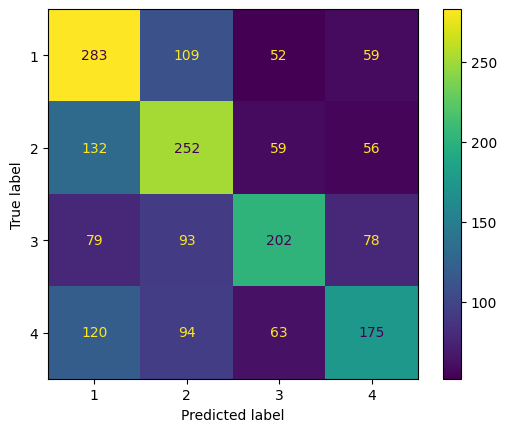

In [12]:
# Model Fitting and Predictions
y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_test, y_pred, ))